In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = pd.read_csv("./data/insurance.csv")
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
print(data.describe(), "\n") # обратить внимания на age, sex, bmi, smoker
print(data.isnull().sum())


               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010 

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


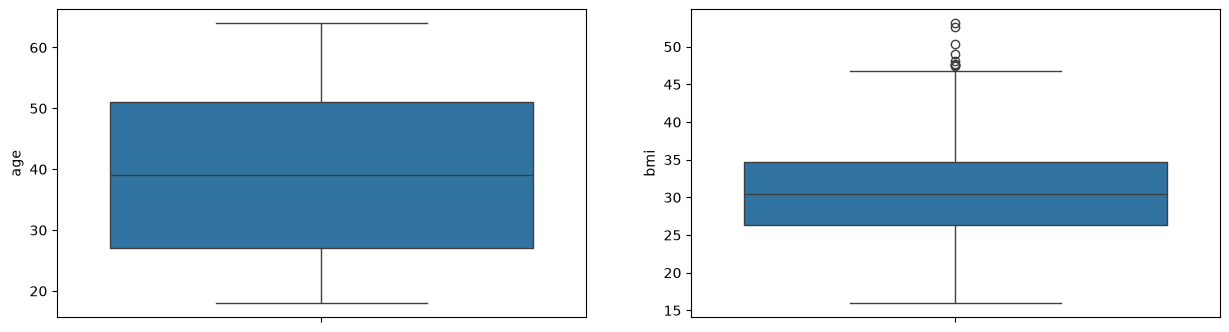

<Axes: xlabel='bmi', ylabel='charges'>

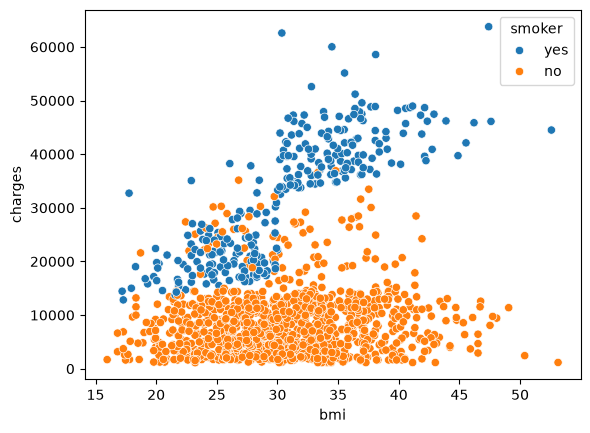

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.boxplot(y=data['age'], ax=axes[0])
sns.boxplot(y=data['bmi'], ax=axes[1])
plt.show()

sns.scatterplot(data=data, x='bmi', y='charges', hue='smoker')

In [5]:
data["sex"] = data["sex"].replace({"female": 0, "male": 1})
data["smoker"] = data["smoker"].replace({"no": 0, "yes": 1})

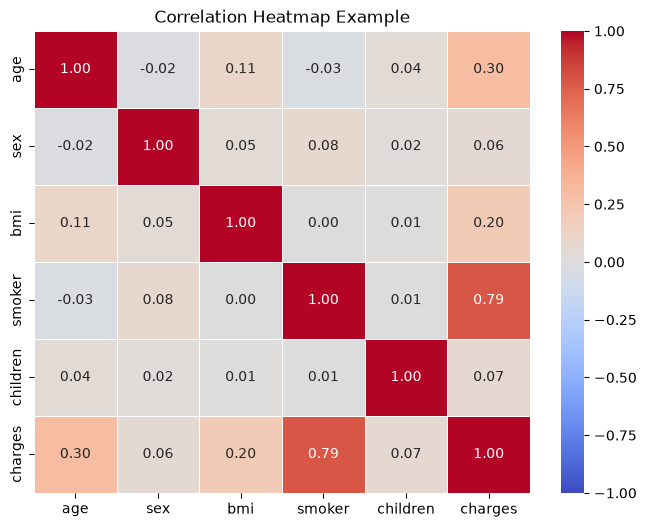

In [6]:
selected_columns = ["age", "sex", "bmi", "smoker", "children", "charges"]
corr_matrix = data[selected_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,  
    cmap="coolwarm", 
    fmt=".2f",  
    vmin=-1,
    vmax=1,  
    linewidths=0.5,  
)

plt.title("Correlation Heatmap Example")
plt.show()

In [7]:
X = data[["age", "bmi", "smoker"]]
y = data["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
alphas = [0.1, 1.0, 10.0, 100.0]
ridge_cv = RidgeCV(alphas=alphas, cv=3)
ridge_cv.fit(X_train_scaled, y_train)

model = Ridge(alpha=ridge_cv.alpha_)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(f"R² score на тесте: {r2_score(y_test, y_pred):.2f}")
print(f"Коэффициенты модели (веса): {model.coef_}")
print("Лучший alpha:", ridge_cv.alpha_)
print("Intercept:", model.intercept_)
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

R² score на тесте: 0.78
Коэффициенты модели (веса): [3612.43637177 1957.6848604  9477.73872845]
Лучший alpha: 10.0
Intercept: 13346.089736364485
RMSE: 5879.897347491103
